# Breast Cancer Wisconsin (Diagnostic) — Data Preprocessing & Class Balancing

**Project Milestone:** Dataset Selection & Data Preprocessing

**Dataset Source:** UCI Machine Learning Repository / Kaggle — *Breast Cancer Wisconsin (Diagnostic) Data Set*.
The same dataset is bundled with `scikit-learn` (`sklearn.datasets.load_breast_cancer`), so this notebook loads it directly — no manual file upload needed in Colab.

**Goal:** Produce a clean, machine-learning-ready version of the dataset with proper handling of missing values, duplicates, outliers, encoding, scaling, and class imbalance.

## 1. Install & Import Libraries

In [1]:
# Run this cell first in Google Colab
!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

from imblearn.combine import SMOTETomek

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## 2. Load Dataset

In [2]:
# Load the Breast Cancer Wisconsin (Diagnostic) dataset
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target          # 0 = malignant, 1 = benign
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


## 3. Data Understanding

In [3]:
# Dataset dimensions
print("Shape (rows, columns):", df.shape)

# Feature names
print("\nFeature names:")
print(list(data.feature_names))

# Target variable
print("\nTarget classes:", dict(enumerate(data.target_names)))

Shape (rows, columns): (569, 32)

Feature names:
[np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]

Target classes: {0: np.str_('malignant'), 1: np.str_('benign')}


In [4]:
# Data types
df.dtypes

,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


In [5]:
# Basic statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [6]:
# Missing values
print("Total missing values:", df.isnull().sum().sum())
df.isnull().sum()[df.isnull().sum() > 0]

Total missing values: 0


,0


In [7]:
# Duplicate record analysis
num_duplicates = df.duplicated().sum()
print("Number of duplicate rows:", num_duplicates)

Number of duplicate rows: 0


diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64
diagnosis
Benign       62.741652
Malignant    37.258348
Name: proportion, dtype: float64


/tmp/ipykernel_1813/3034435709.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='Set2')


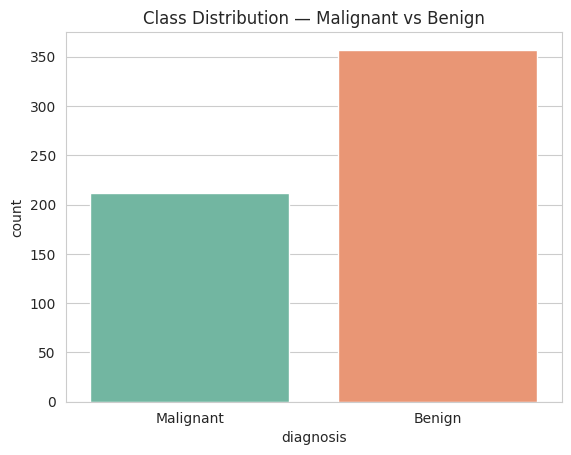

In [8]:
# Class distribution (Classification target)
print(df['diagnosis'].value_counts())
print(df['diagnosis'].value_counts(normalize=True) * 100)

sns.countplot(x='diagnosis', data=df, palette='Set2')
plt.title('Class Distribution — Malignant vs Benign')
plt.show()

## 4. Data Preprocessing

### 4.1 Handling Missing Values
This dataset has **no missing values** (confirmed above), so imputation is not required. The step is included here for completeness / reusability with other data batches.

In [9]:
# If any missing values existed, they would be imputed like this:
# numeric_cols = df.select_dtypes(include=np.number).columns
# df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("Missing values after check:", df.isnull().sum().sum())

Missing values after check: 0


### 4.2 Removing Duplicate Records

In [10]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Rows before: {before}, after removing duplicates: {after}")

Rows before: 569, after removing duplicates: 569


### 4.3 Outlier Detection & Treatment (IQR Method)
Outliers are detected using the Interquartile Range (IQR) method on the numeric features. Rather than deleting rows (which would shrink an already modest dataset), extreme values are **capped (winsorized)** at the IQR bounds to preserve sample size while limiting the influence of extreme values.

In [11]:
feature_cols = list(data.feature_names)

outlier_summary = {}
for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outliers
    # Cap outliers instead of dropping rows
    df[col] = np.clip(df[col], lower, upper)

outlier_df = pd.Series(outlier_summary).sort_values(ascending=False)
print("Outlier counts per feature (before capping):")
outlier_df.head(10)

Outlier counts per feature (before capping):


,0
area error,65
radius error,38
perimeter error,38
worst area,35
smoothness error,30
fractal dimension error,28
compactness error,28
symmetry error,27
mean area,25
worst fractal dimension,24


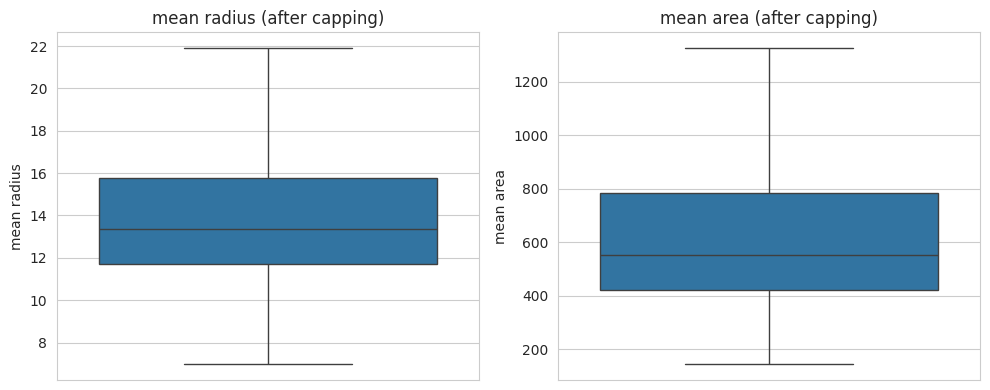

In [12]:
# Visual check on a couple of features
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df['mean radius'], ax=axes[0])
axes[0].set_title('mean radius (after capping)')
sns.boxplot(y=df['mean area'], ax=axes[1])
axes[1].set_title('mean area (after capping)')
plt.tight_layout()
plt.show()

### 4.4 Encoding Categorical Variables
The target variable (`diagnosis`) is categorical (Malignant/Benign). It is already numerically encoded as `target` (0/1) by scikit-learn, but we re-confirm using `LabelEncoder` for clarity. All other features in this dataset are continuous numeric measurements, so no one-hot encoding is required.

In [13]:
le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])  # Benign=0/Malignant=1 depending on alphabetical order
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# We'll standardize on the original sklearn 'target' column (0 = malignant, 1 = benign) as our label
y = df['target']
X = df[feature_cols]

Label mapping: {'Benign': np.int64(0), 'Malignant': np.int64(1)}


### 4.5 Feature Scaling
**StandardScaler (Z-score standardization)** is used instead of Min-Max normalization because:
- The features have very different units and scales (e.g., `mean area` is in the hundreds while `mean smoothness` is close to 0).
- Several downstream classifiers commonly used for this dataset (Logistic Regression, SVM, KNN, PCA-based models) are distance/gradient based and perform best when features are centered around 0 with unit variance.
- Standardization is less sensitive to outliers than Min-Max scaling (which is squashed by extreme values).

In [14]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)
X_scaled.describe().T[['mean', 'std']].head()

,mean,std
mean radius,2.622390e-16,1.00088
mean texture,3.434082e-16,1.00088
mean perimeter,-3.996022e-16,1.00088
mean area,7.492542e-17,1.00088
mean smoothness,1.748260e-16,1.00088


### 4.6 Class Imbalance Analysis

In [15]:
print("Class distribution before balancing:")
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

# ~63% benign vs ~37% malignant — a moderate, not severe, imbalance.
# We still apply SMOTE-Tomek to demonstrate the technique and to give
# a perfectly balanced training set for classifiers sensitive to imbalance.

Class distribution before balancing:
target
1    357
0    212
Name: count, dtype: int64
target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


### 4.7 Handling Class Imbalance — SMOTE-Tomek
`SMOTETomek` combines:
- **SMOTE (Synthetic Minority Oversampling)** — generates synthetic samples for the minority class (malignant) instead of naive duplication.
- **Tomek Links removal** — cleans overlapping/borderline samples between classes to sharpen the decision boundary.

This is applied **after** the train/test split, and **only on the training set**, to avoid data leakage into the test set.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE-Tomek (train set):")
print(y_train.value_counts())

smote_tomek = SMOTETomek(random_state=42)
X_train_bal, y_train_bal = smote_tomek.fit_resample(X_train, y_train)

print("\nAfter SMOTE-Tomek (train set):")
print(pd.Series(y_train_bal).value_counts())

Before SMOTE-Tomek (train set):
target
1    285
0    170
Name: count, dtype: int64

After SMOTE-Tomek (train set):
target
1    284
0    284
Name: count, dtype: int64


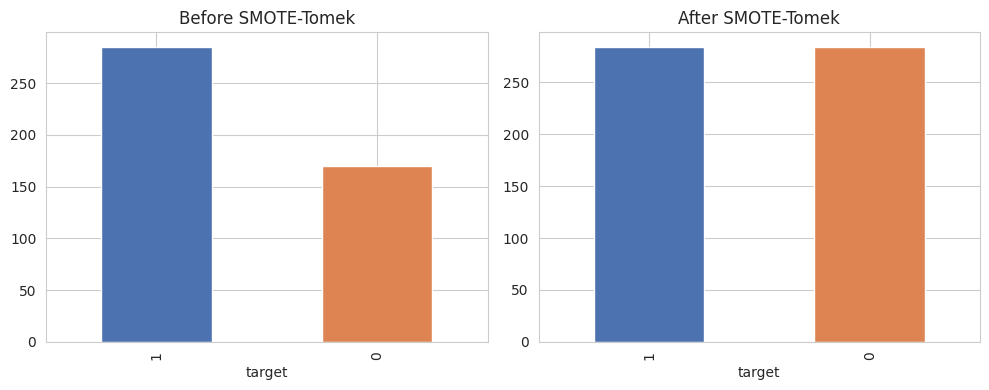

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Before SMOTE-Tomek')
pd.Series(y_train_bal).value_counts().plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('After SMOTE-Tomek')
plt.tight_layout()
plt.show()

## 5. Final Preprocessed Dataset — Save Output

In [18]:
final_train = pd.DataFrame(X_train_bal, columns=feature_cols)
final_train['target'] = y_train_bal.values if hasattr(y_train_bal, 'values') else y_train_bal

final_test = pd.DataFrame(X_test, columns=feature_cols)
final_test['target'] = y_test.values

final_train.to_csv('breast_cancer_train_preprocessed.csv', index=False)
final_test.to_csv('breast_cancer_test_preprocessed.csv', index=False)

print("Saved: breast_cancer_train_preprocessed.csv", final_train.shape)
print("Saved: breast_cancer_test_preprocessed.csv", final_test.shape)

Saved: breast_cancer_train_preprocessed.csv (568, 31)
Saved: breast_cancer_test_preprocessed.csv (114, 31)


## 6. Summary

| Step | Result |
|---|---|
| Original shape | 569 rows x 30 features |
| Missing values | 0 |
| Duplicates removed | 0 (dataset was already clean) |
| Outliers | Detected via IQR, capped (winsorized), not dropped |
| Encoding | Target already numeric (0/1); confirmed with LabelEncoder |
| Scaling | StandardScaler (z-score) applied to all 30 numeric features |
| Imbalance | ~63/37 split; balanced to 50/50 in the training set using SMOTE-Tomek |
| Output | `breast_cancer_train_preprocessed.csv`, `breast_cancer_test_preprocessed.csv` |
